ASEN-6062
Celestial Mechanics
Final Project
Nicole James

Temporary capture of particles in Earth-Moon 2BP starting with CR3BP

L1 Lagrange Point: [0.84058138 0.         0.        ]
Position of Moon relative to L1: [0.14726408 0.         0.        ]
Jacobi constant at L1: 3.1885331914493253
Effective potential at particle's position: 1.5943128235943305
Jacobi constant at initial state: 3.1885256471886607


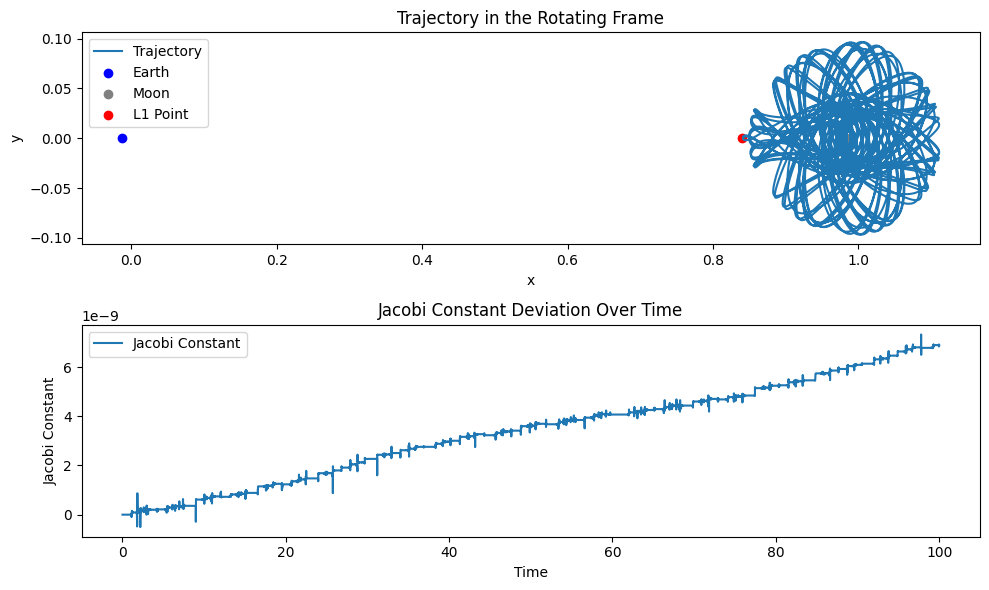

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy

def constants():
    G = 1.0             # Gravitational constant (normalized)
    M1 = 5.972e24       # Mass of Earth (primary)
    M2 = 7.348e22       # Mass of Moon (secondary)
    M3 = 1e-20          # Mass of tertiary (small asteroid)
    omega = 1.0         # Angular velocity magnitude (normalized)
    Omega = np.array([0, 0, 1]) * omega  # Angular velocity of the rotating frame
    mu = M2 / (M1 + M2)
    pos_earth = -mu * np.array([1, 0, 0])  # Earth at (mu, 0, 0)
    pos_moon = (1 - mu) * np.array([1, 0, 0])
    return G, M1, M2, M3, mu, pos_earth, pos_moon

def calc_com(masses, pos):
    M = np.sum(masses)
    com = np.sum(pos * masses[:, None], axis=0) / M
    return com

def compute_L1_coordinates(G, mu, M1, M2):
    r = 1.0   # Distance between primary and secondary
    L1_x = r* (1 - (mu / 3)**(1/3))
    return np.array([L1_x, 0, 0])

def compute_L2_coordinates(G, mu, M1, M2):
    r = 1.0   # Distance between primary and secondary
    L2_x = r* (1 + (mu / 3)**(1/3))
    return np.array([L2_x, 0, 0])

def effective_potential(G, mu, pos_earth, pos_moon, pos_particle):
    r1 = np.linalg.norm(pos_particle - pos_earth)  # Distance to Earth
    r2 = np.linalg.norm(pos_particle - pos_moon)   # Distance to Moon
    potential = G * (1 - mu) / r1 + G * mu / r2 + 0.5 * np.linalg.norm(pos_particle[0:2])**2
    return potential

def calc_Jacobi_constant(state, mu):
    G, _, _, _, _, pos_earth, pos_moon = constants()
    U = effective_potential(G, mu, pos_earth, pos_moon, state[:3])
    v_squared = np.linalg.norm(state[3:])**2
    jacobi = 2*U - v_squared
    return jacobi

def equations_of_motion(t, state, mu, masses):
    x, y, z, vx, vy, vz = state
    xdot  = vx
    ydot  = vy
    zdot  = vz

    r1 = np.sqrt((x+mu)**2 + y**2 + z**2)
    r2 = np.sqrt((x-1+mu)**2 + y**2 + z**2)

    vxdot = 2*vy + x - (1-mu)*(x+mu)/r1**3 - mu*(x-1+mu)/r2**3
    vydot = -2*vx + y - (1-mu)*y/r1**3 - mu*y/r2**3
    vzdot = -(1-mu)*z/r1**3 - mu*z/r2**3
    return [xdot, ydot, zdot, vxdot, vydot, vzdot]

def integrate_orbits(mu, masses, initial_state, t_span, dt):
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
    
    sol = solve_ivp(
        fun=equations_of_motion,
        t_span=t_span,
        y0=initial_state,
        args=(mu, masses),
        t_eval=t_eval,
        method='DOP853',
        rtol=1e-10,
        atol=1e-12
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2], sol.y[3], sol.y[4], sol.y[5]

def trajectory_analysis(mu, masses, initial_state, t_span, dt):
    t, x, y, z, vx, vy, vz = integrate_orbits(mu, masses, initial_state, t_span, dt)
    jacobi_constants = np.array([calc_Jacobi_constant(state, mu) for state in zip(x, y, z, vx, vy, vz)])
    return t, x, y, z, vx, vy, vz, jacobi_constants
  

# Inside the Moon's Hill sphere: r2<rH≈(μ3)1/3r2 <rH ≈(3μ )1/3
# Negative Kepler energy w.r.t. the Moon: E2=12∣vrel∣2−μr2<0E2 =21 ∣vrel ∣2−r2 μ <0
def is_captured(state, mu):
    """Check if particle is temporarily captured by the Moon."""
    x, y, z, vx, vy, vz = state
    # Moon position in rotating frame
    x_moon = 1 - mu
    
    # Distance to Moon
    r2 = np.sqrt((x - x_moon)**2 + y**2 + z**2)
    
    # Hill sphere radius
    r_hill = (mu / 3)**(1/3)
    
    # Kepler energy relative to the Moon
    v_rel_sq = vx**2 + vy**2 + vz**2
    E2 = 0.5 * v_rel_sq - mu / r2
    
    return (r2 < r_hill) and (E2 < 0)



G, M1, M2, M3, mu, pos_earth, pos_moon = constants()
L1 = compute_L1_coordinates(G, mu, M1, M2)
print(f"L1 Lagrange Point: {L1}")

print(f"Position of Moon relative to L1: {pos_moon - L1}")

# jacobi constant at L1
jacobi_L1 = calc_Jacobi_constant(np.concatenate((L1, np.zeros(3))), mu)
print(f"Jacobi constant at L1: {jacobi_L1}")

pos_particle = L1 + np.array([0.001, 0.001, 0])  # Initial position of the particle
vel_particle = np.array([0.0, 0.01, 0])  # Initial velocity of the particle
potential = effective_potential(G, mu, pos_earth, pos_moon, pos_particle)
print(f"Effective potential at particle's position: {potential}")

jacobi_0 = calc_Jacobi_constant(np.concatenate((pos_particle, vel_particle)), mu)
print(f"Jacobi constant at initial state: {jacobi_0}")

masses = np.array([M1, M2, M3])
initial_state = np.concatenate((pos_particle, vel_particle))
t_span = (0, 100)  # Time span for integration
dt = 0.01  # Time step for integration
t, x, y, z, vx, vy, vz, jacobi_constants = trajectory_analysis(mu, masses, initial_state, t_span, dt)

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(x, y, label='Trajectory')
plt.scatter(pos_earth[0], pos_earth[1], color='blue', label='Earth')
plt.scatter(pos_moon[0], pos_moon[1], color='gray', label='Moon')
plt.scatter(L1[0], L1[1], color='red', label='L1 Point')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trajectory in the Rotating Frame')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t, jacobi_constants-jacobi_0, label='Jacobi Constant')
plt.xlabel('Time')
plt.ylabel('Jacobi Constant')
plt.title('Jacobi Constant Deviation Over Time')
plt.legend()
plt.tight_layout()
plt.show()  



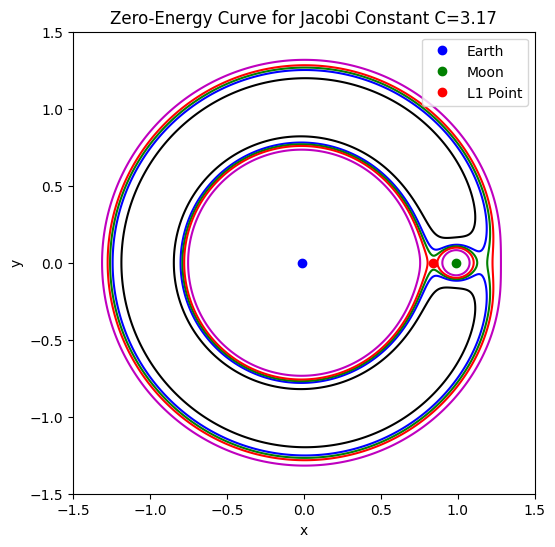

In [2]:
# calculate zero-energy curve for the given Jacobi constant

x = np.linspace(-1.5, 1.5, 400)
y = np.linspace(-1.5, 1.5, 400)

x,y = np.meshgrid(x,y)

r1 = np.sqrt((x+mu)**2 + y**2)
r2 = np.sqrt((x-1+mu)**2 + y**2)

V = G * (1 - mu) / r1 + G * mu / r2 + 0.5 * (x**2 + y**2)

plt.figure(figsize=(10, 6))
plt.contour(x, y, 2*V, levels=[3.10,3.16,3.18,3.20,3.25], 
            colors=['k','b','g','r','m'])
plt.gca().set_aspect('equal')
plt.plot(pos_earth[0], pos_earth[1], 'bo', label='Earth')
plt.plot(pos_moon[0], pos_moon[1], 'go', label='Moon')
plt.plot(L1[0], L1[1], 'ro', label='L1 Point')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Zero-Energy Curve for Jacobi Constant C=3.17')
plt.legend()
plt.show()



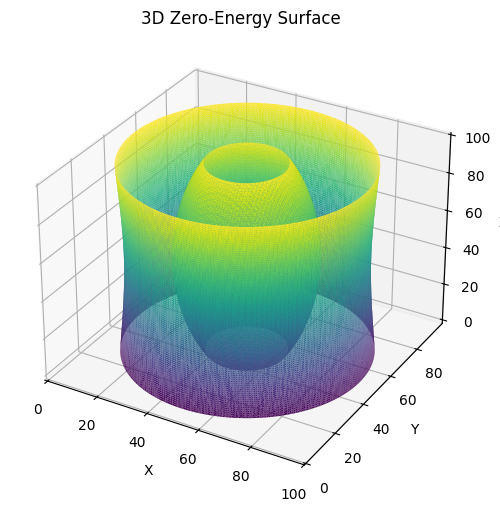

In [3]:
from skimage import measure

# generate 3-d zero velocity curves
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
z = np.linspace(-0.5, 0.5, 100)

x,y,z = np.meshgrid(x,y,z)
r1 = np.sqrt((x+mu)**2 + y**2 + z**2)
r2 = np.sqrt((x-1+mu)**2 + y**2 + z**2)
U = G * (1 - mu) / r1 + G * mu / r2 + 0.5 * (x**2 + y**2)
F = 2*U - jacobi_0
verts, faces, _, _ = measure.marching_cubes(F, level=0)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
# mesh = Poly3DCollection(verts[faces], alpha=0.2)
# mesh.set_edgecolor('none')

mesh = ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2], cmap='viridis', lw=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D Zero-Energy Surface')
plt.show()


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# --- CR3BP setup ---
mu = 0.0121505856  # Earth-Moon

# grid
x = np.linspace(-1.5, 1.5, 300)
y = np.linspace(-1.5, 1.5, 300)
X, Y = np.meshgrid(x, y)

r1 = np.sqrt((X + mu)**2 + Y**2)
r2 = np.sqrt((X - 1 + mu)**2 + Y**2)
U = (1 - mu)/r1 + mu/r2 + 0.5*(X**2 + Y**2)  # effective potential in plane
twoU = 2*U

# choose C values (high -> closed; low -> open)
C_vals = np.linspace(3.05, 3.25, 60)

fig, ax = plt.subplots(figsize=(7, 6))
plt.close(fig)

def update(i):
    ax.clear()
    C = C_vals[i]
    F = twoU - C

    ax.contourf(X, Y, F, levels=[F.min(), 0], colors=['black'], alpha=0.35)
    ax.contour(X, Y, F, levels=[0], colors='red', linewidths=2)

    ax.plot(-mu, 0, 'bo', ms=8)
    ax.plot(1-mu, 0, 'ko', ms=4)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Hill Region Opening (C = {C:.4f})")

ani = FuncAnimation(fig, update, frames=len(C_vals), blit=False, interval=80)

display(HTML(ani.to_jshtml()))

In [5]:
# Monte Carlo simulation of trajectories near L1
G, M1, M2, M3, mu, pos_earth, pos_moon = constants()
L1 = compute_L1_coordinates(G, mu, M1, M2)
print(f"L1 Lagrange Point: {L1}")



L1 Lagrange Point: [0.84058138 0.         0.        ]


In [6]:
# ── Temporary capture from ICs outside Moon Hill sphere ──────────
# Pick initial conditions with CJ between CJ(L1) and CJ(L2) so the
# L1 neck is open. Start on the Earth side, just outside the Hill sphere.

from scipy.signal import argrelmin
from matplotlib.patches import Circle

G, M1, M2, M3, mu, pos_earth, pos_moon = constants()
L1 = compute_L1_coordinates(G, mu, M1, M2)
L2 = compute_L2_coordinates(G, mu, M1, M2)

r_hill = (mu / 3) ** (1 / 3)
x_moon = 1 - mu

# Reference Jacobi constants at L1 and L2 (zero velocity at those points)
CJ_L1 = calc_Jacobi_constant(np.concatenate((L1, np.zeros(3))), mu)
CJ_L2 = calc_Jacobi_constant(np.concatenate((L2, np.zeros(3))), mu)

print(f"L1: x = {L1[0]:.6f},  CJ = {CJ_L1:.6f}")
print(f"L2: x = {L2[0]:.6f},  CJ = {CJ_L2:.6f}")
print(f"Moon: x = {x_moon:.6f}")
print(f"Hill sphere radius: {r_hill:.4f}  ({r_hill * 384400:.0f} km)")
print()

# ── Initial conditions ──────────────────────────────────────────────
# Position: Earth side of L1, on x-axis, outside Moon's Hill sphere
x0 = L1[0] - 0.015       # just Earth-ward of L1
y0, z0 = 0.0, 0.0
vx0, vz0 = 0.0, 0.0      # crossing x-axis headed "up"

# Target CJ: slightly below CJ(L1) so L1 neck is open but narrow
CJ_target = 0.5 * (CJ_L1 + CJ_L2)

# Solve for vy: CJ = 2*U - v^2  =>  vy = sqrt(2*U - CJ - vx^2 - vz^2)
pos0 = np.array([x0, y0, z0])
U0 = effective_potential(G, mu, pos_earth, pos_moon, pos0)
vy_sq = 2 * U0 - CJ_target - vx0**2 - vz0**2
assert vy_sq > 0, f"CJ target not achievable at x0={x0} (vy^2 = {vy_sq})"
vy0 = np.sqrt(vy_sq)

state0 = np.array([x0, y0, z0, vx0, vy0, vz0])
CJ_actual = calc_Jacobi_constant(state0, mu)

dist_to_moon_0 = np.sqrt((x0 - x_moon)**2 + y0**2 + z0**2)
print(f"IC: x0={x0:.4f}, y0={y0}, vy0={vy0:.6f}")
print(f"Distance to Moon: {dist_to_moon_0:.4f}  (Hill = {r_hill:.4f})")
print(f"Outside Hill sphere: {dist_to_moon_0 > r_hill}")
print(f"CJ = {CJ_actual:.6f}  (L1={CJ_L1:.6f}, L2={CJ_L2:.6f})")

# ── Propagate ───────────────────────────────────────────────────────
masses = np.array([M1, M2, M3])
T_lunar = 2 * np.pi
n_orbits = 12
t_span = (0, n_orbits * T_lunar)
dt = 0.005

t, x, y, z, vx, vy, vz, cj_hist = trajectory_analysis(
    mu, masses, state0, t_span, dt
)

# Distance to Moon at each time step
dist_moon = np.sqrt((x - x_moon)**2 + y**2 + z**2)
inside_hill = dist_moon < r_hill

# ── Capture analysis ────────────────────────────────────────────────
transitions = np.diff(inside_hill.astype(int))
entries = np.where(transitions == 1)[0]
exits   = np.where(transitions == -1)[0]

print(f"\n─── Capture Analysis ({n_orbits} lunar orbits) ───")
print(f"Min distance to Moon: {np.min(dist_moon):.4f}")
print(f"Time inside Hill sphere: {np.mean(inside_hill):.1%}")

if len(entries) > 0:
    print(f"Hill sphere entries: {len(entries)}")
    for i, ent in enumerate(entries[:8]):
        later_exits = exits[exits > ent]
        if len(later_exits) > 0:
            ext = later_exits[0]
            dur = t[ext] - t[ent]
            print(f"  #{i+1}: t={t[ent]:.2f} -> {t[ext]:.2f}  "
                  f"({dur:.2f} = {dur/T_lunar:.2f} lunar orbits)")
        else:
            print(f"  #{i+1}: t={t[ent]:.2f} -> still inside at end")
else:
    print("No Hill sphere entries.")

# Periapsis passages
peri_idx = argrelmin(dist_moon, order=30)[0]
peri_in  = [i for i in peri_idx if inside_hill[i]]
print(f"Periapsis passages (total): {len(peri_idx)}")
print(f"Periapsis inside Hill sphere: {len(peri_in)}")

# Check capture flag at each step
cap_flags = [is_captured(s, mu)
             for s in zip(x, y, z, vx, vy, vz)]
print(f"Steps with bound capture (E2<0 & inside Hill): "
      f"{sum(cap_flags)} / {len(cap_flags)}")

# ── Plotting ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    f"CR3BP Temporary Capture — CJ={CJ_actual:.4f} "
    f"(L1: {CJ_L1:.4f}, L2: {CJ_L2:.4f})",
    fontsize=13,
)

# (a) Full trajectory
ax = axes[0, 0]
ax.plot(x, y, 'b-', lw=0.3, alpha=0.6, label='Trajectory')
ax.plot(pos_earth[0], pos_earth[1], 'co', ms=10, label='Earth')
ax.plot(x_moon, 0, 'ko', ms=6, label='Moon')
ax.plot(L1[0], 0, 'r^', ms=8, label='L1')
ax.plot(L2[0], 0, 'rv', ms=8, label='L2')
ax.plot(x[0], y[0], 'g*', ms=12, label='Start')
ax.add_patch(Circle((x_moon, 0), r_hill, fill=False,
                     color='gray', ls='--', label='Hill sphere'))
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Full Trajectory (rotating frame)')
ax.legend(fontsize=7, loc='upper left')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# (b) Zoom on Moon
ax = axes[0, 1]
ax.plot(x, y, 'b-', lw=0.5, alpha=0.6)
for ent in entries:
    later_exits = exits[exits > ent]
    ext = later_exits[0] if len(later_exits) > 0 else len(t) - 1
    ax.plot(x[ent:ext], y[ent:ext], 'r-', lw=1.0, alpha=0.8)
ax.plot(x_moon, 0, 'ko', ms=8)
ax.add_patch(Circle((x_moon, 0), r_hill, fill=False,
                     color='gray', ls='--'))
ax.plot(L1[0], 0, 'r^', ms=8)
ax.plot(L2[0], 0, 'rv', ms=8)
ax.set_xlim(x_moon - 0.3, x_moon + 0.3)
ax.set_ylim(-0.3, 0.3)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Zoom: Moon (red = inside Hill sphere)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# (c) Distance to Moon
ax = axes[1, 0]
ax.plot(t / T_lunar, dist_moon, 'b-', lw=0.5)
ax.axhline(r_hill, color='gray', ls='--',
           label=f'Hill radius = {r_hill:.3f}')
ax.fill_between(t / T_lunar, 0, dist_moon,
                where=inside_hill, alpha=0.3, color='red',
                label='Inside Hill sphere')
ax.set_xlabel('Time (lunar orbits)')
ax.set_ylabel('Distance to Moon')
ax.set_title('Distance to Moon vs Time')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (d) Zero-velocity curves + trajectory
ax = axes[1, 1]
xg = np.linspace(-1.5, 1.5, 400)
yg = np.linspace(-1.5, 1.5, 400)
Xg, Yg = np.meshgrid(xg, yg)
r1g = np.sqrt((Xg + mu)**2 + Yg**2)
r2g = np.sqrt((Xg - 1 + mu)**2 + Yg**2)
twoU = 2 * ((1-mu)/r1g + mu/r2g + 0.5*(Xg**2 + Yg**2))
ax.contour(Xg, Yg, twoU, levels=[CJ_actual], colors='red', linewidths=1.5)
ax.contourf(Xg, Yg, twoU, levels=[CJ_actual, 100], colors=['gray'], alpha=0.3)
ax.plot(x, y, 'b-', lw=0.3, alpha=0.5)
ax.plot(pos_earth[0], 0, 'co', ms=10)
ax.plot(x_moon, 0, 'ko', ms=6)
ax.plot(L1[0], 0, 'r^', ms=8); ax.plot(L2[0], 0, 'rv', ms=8)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Zero-Velocity Curve at CJ = {CJ_actual:.4f}')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


L1: x = 0.840581,  CJ = 3.188533
L2: x = 1.159419,  CJ = 3.172292
Moon: x = 0.987845
Hill sphere radius: 0.1594  (61281 km)

IC: x0=0.8256, y0=0.0, vy0=0.096712
Distance to Moon: 0.1623  (Hill = 0.1594)
Outside Hill sphere: True
CJ = 3.180413  (L1=3.188533, L2=3.172292)


ValueError: Values in `t_eval` are not within `t_span`.

In [ ]:
# generate values of Jacobi constant values for trajectories near L1
num_trajectories = 100
captured_traj = []

for _ in range(num_trajectories):
    pos_particle = L1 + np.random.uniform(-0.1, 0.1, size=3)
    vel_particle = np.random.uniform(-0.01, 0.01, size=3)
    initial_state = np.concatenate((pos_particle, vel_particle))
    jacobi = calc_Jacobi_constant(initial_state, mu)
    t_span = (0, 100)
    dt = 0.01
    t, x, y, z, vx, vy, vz = integrate_orbits(mu, masses, initial_state, t_span, dt)
     
    captured_flags = [is_captured(s, mu) for s in zip(x, y, z, vx, vy, vz)]

    # Temporary capture = enters and then exits a captured state
    if any(captured_flags):
        # Count consecutive captured segments, or measure capture duration
        capture_duration = np.sum(captured_flags) * dt
        print(f"Captured for {capture_duration:.2f} time units with Jacobi constant {jacobi:.4f} and initial state {initial_state}  ")

        # append initial state and jacobi constant of captured trajectory
        captured_traj.append((initial_state, jacobi))


print(f"Number of captured trajectories: {len(captured_traj)} out of {num_trajectories}")


Captured for 100.01 time units with Jacobi constant 3.3015 and initial state [ 0.93358306 -0.02598798  0.03757053 -0.00133199  0.00833496 -0.00138477]  
Captured for 4.92 time units with Jacobi constant 3.1547 and initial state [ 8.47852491e-01 -7.40330328e-02  5.21682753e-02  9.64653490e-03
 -1.41416291e-03 -6.91788427e-04]  
Captured for 14.77 time units with Jacobi constant 3.1714 and initial state [ 0.83664224 -0.04395014  0.04517056  0.00897234  0.00295208 -0.0051815 ]  
Captured for 100.01 time units with Jacobi constant 3.2408 and initial state [ 9.13220857e-01  4.82294273e-02  8.07030179e-03  4.97229887e-03
 -5.39933355e-03  1.45629864e-04]  
Captured for 9.60 time units with Jacobi constant 3.1762 and initial state [ 0.84943519  0.0140339  -0.04771028 -0.00091171  0.00677709  0.00112935]  
Captured for 100.01 time units with Jacobi constant 3.1506 and initial state [0.93834637 0.06898595 0.08628767 0.00530997 0.00515196 0.00679399]  
Captured for 100.01 time units with Jacobi 

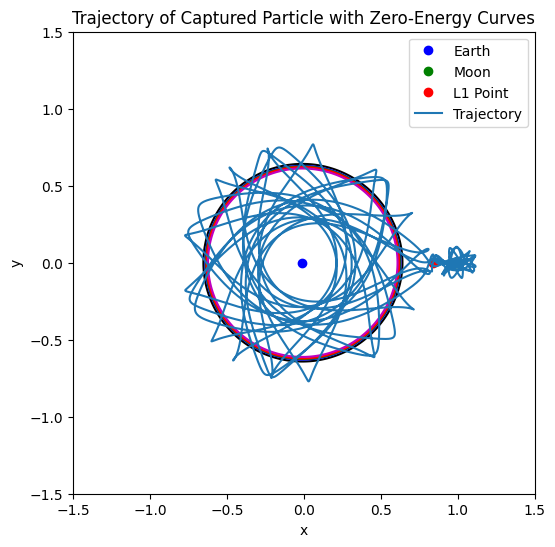

In [ ]:
# now plot the trajectory of the captured particle in the rotating frame, along with the zero-velocity curve for its Jacobi constant
state = [0.90890911, -0.08261452, -0.0432262, -0.00970273, -0.00441134, -0.00462622]
jacobi - 3.1659
t_span = (0, 100)
dt = 0.01
G, M1, M2, M3, mu, pos_earth, pos_moon = constants()
t, xt, yt, z, vx, vy, vz = integrate_orbits(mu, [M1, M2, M3], state, t_span, dt)

# calculate zero-energy curve for the given Jacobi constant
xg = np.linspace(-1.5, 1.5, 400)
yg = np.linspace(-1.5, 1.5, 400)
xg, yg = np.meshgrid(xg, yg)
r1 = np.sqrt((xg+mu)**2 + yg**2)
r2 = np.sqrt((xg-1+mu)**2 + yg**2)
V = G * (1 - mu) / r1 + G * mu / r2
plt.figure(figsize=(10, 6))
plt.contour(xg, yg, 2*V, levels=[3.10,3.16,3.18,3.20,3.25], 
            colors=['k','b','g','r','m'])
plt.gca().set_aspect('equal')
plt.plot(pos_earth[0], pos_earth[1], 'bo', label='Earth')
plt.plot(pos_moon[0], pos_moon[1], 'go', label='Moon')
plt.plot(L1[0], L1[1], 'ro', label='L1 Point')
plt.plot(xt, yt, label='Trajectory')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trajectory of Captured Particle with Zero-Energy Curves')
plt.legend()
plt.show()


Trajectory 2 is temporarily captured by the Moon.


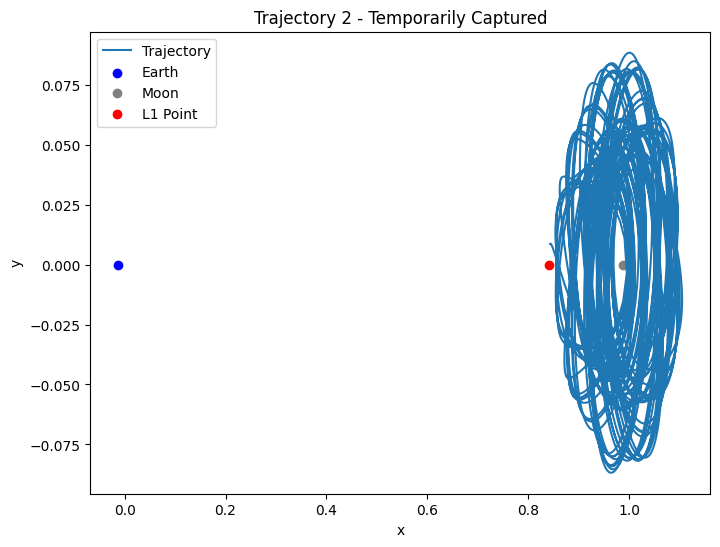

Trajectory 4 is temporarily captured by the Moon.


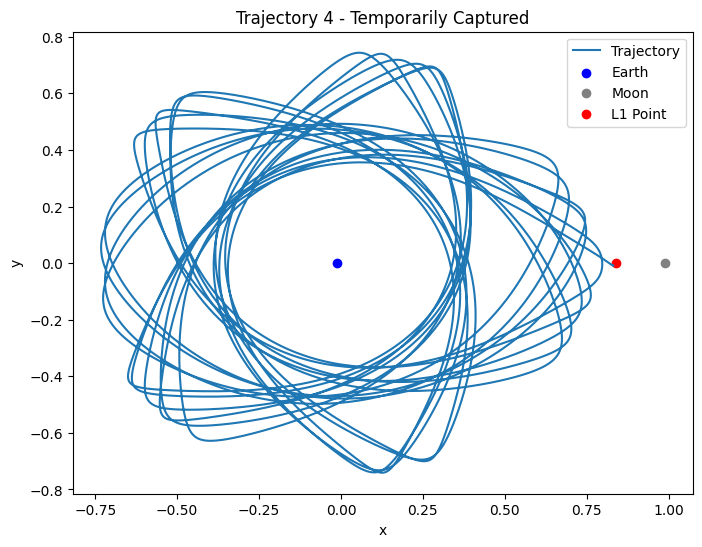

Trajectory 5 is temporarily captured by the Moon.


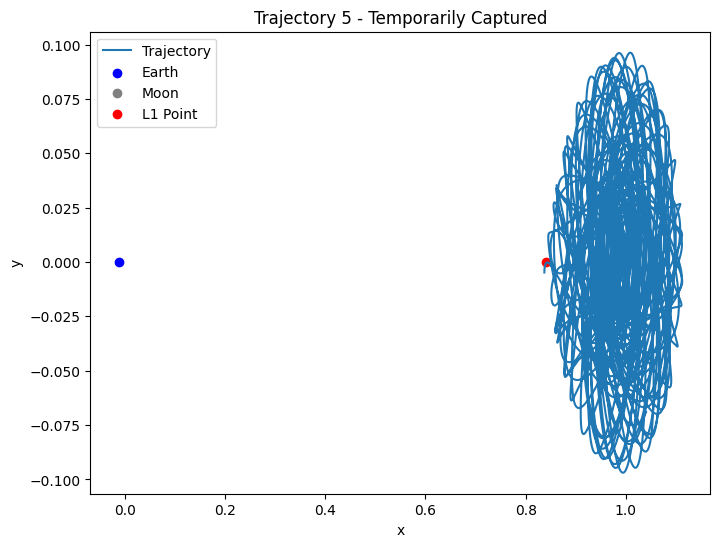

Trajectory 8 is temporarily captured by the Moon.


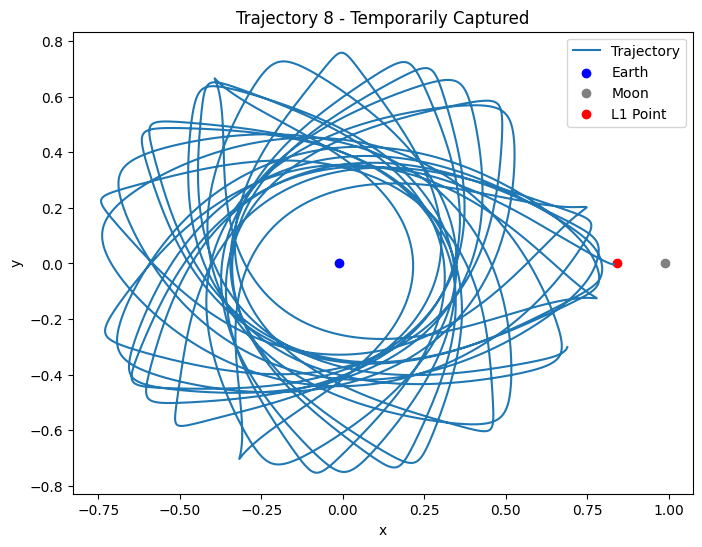

Trajectory 11 is temporarily captured by the Moon.


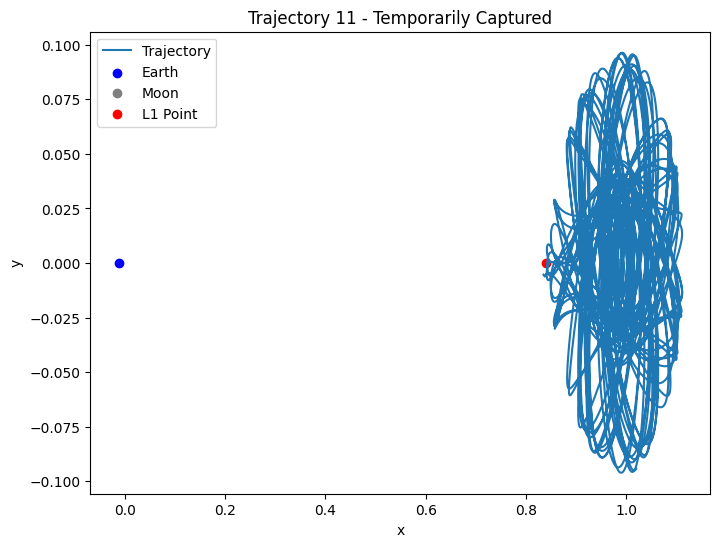

Trajectory 13 is temporarily captured by the Moon.


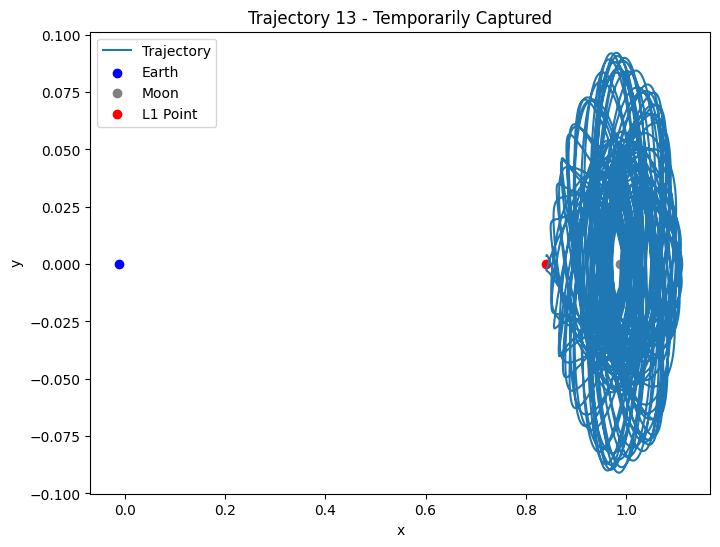

Trajectory 15 is temporarily captured by the Moon.


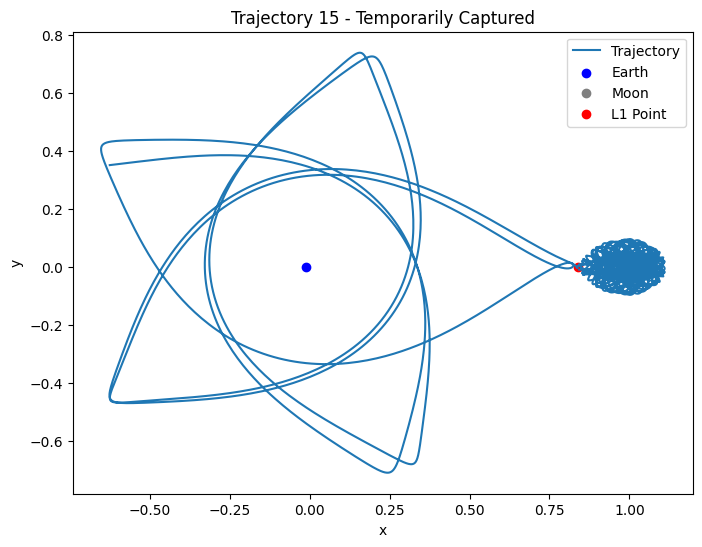

Trajectory 16 is temporarily captured by the Moon.


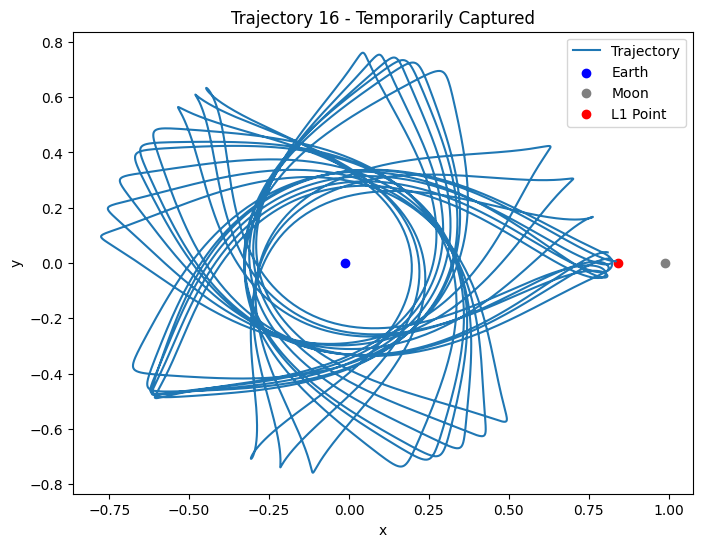

Trajectory 17 is temporarily captured by the Moon.


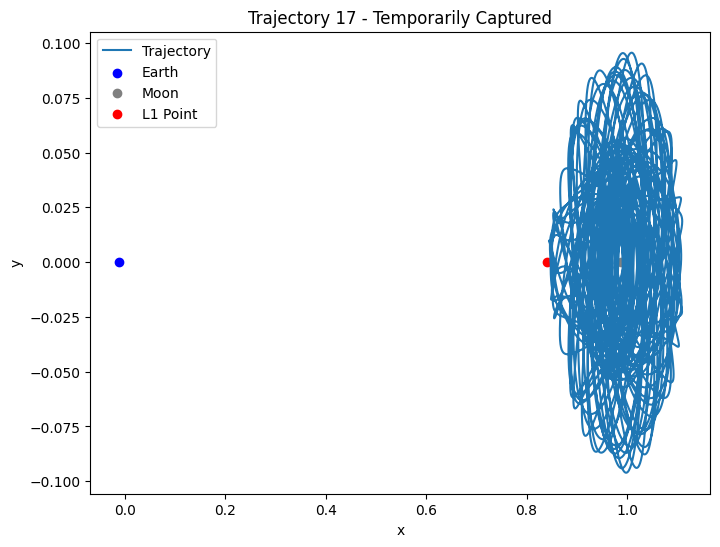

Trajectory 18 is temporarily captured by the Moon.


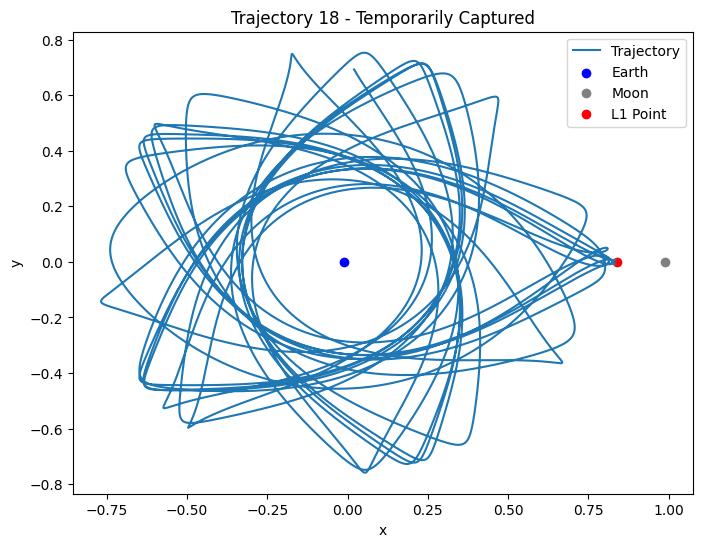

Trajectory 19 is temporarily captured by the Moon.


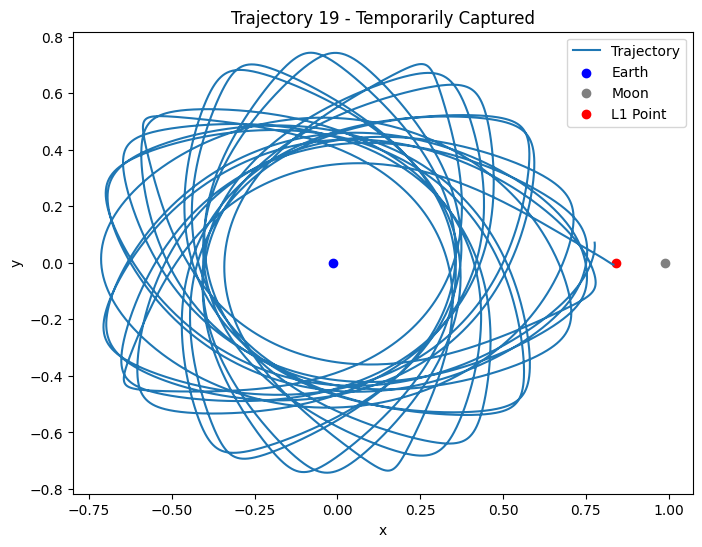

Trajectory 20 is temporarily captured by the Moon.


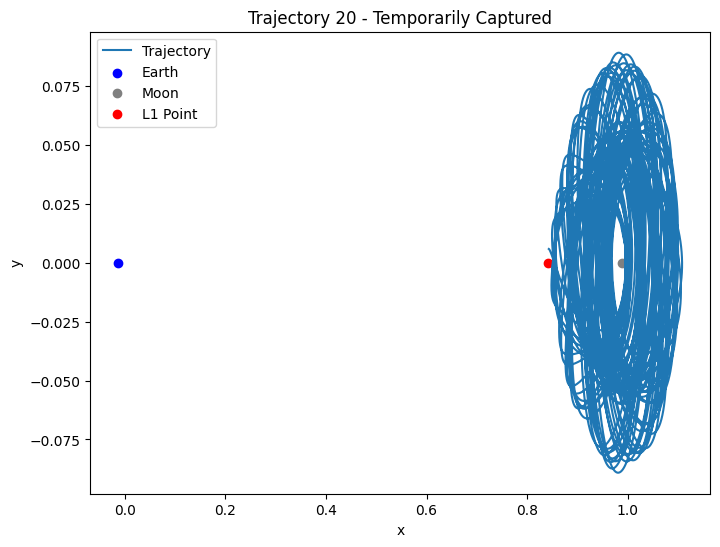

Trajectory 21 is temporarily captured by the Moon.


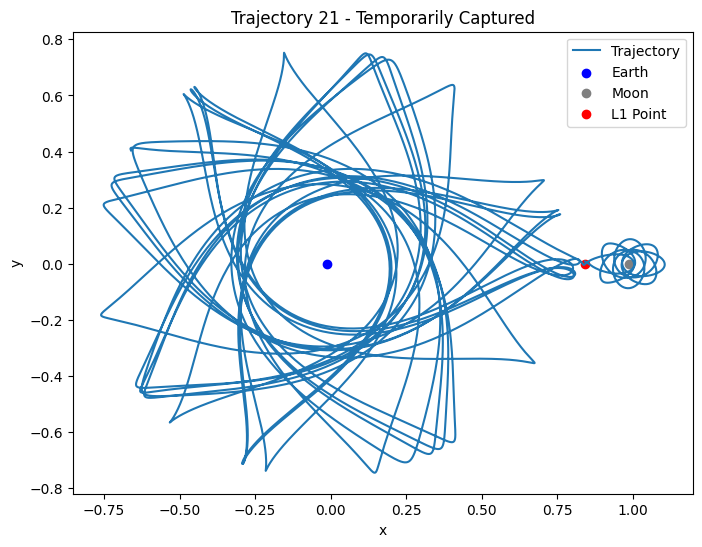

Trajectory 23 is temporarily captured by the Moon.


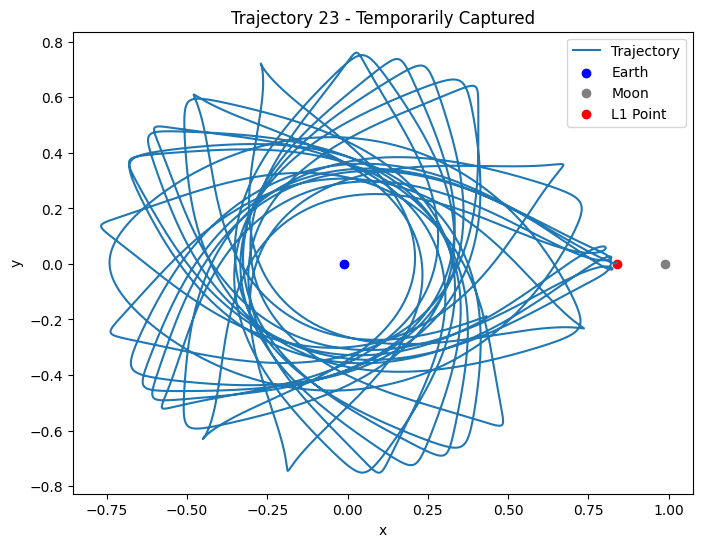

Trajectory 24 is temporarily captured by the Moon.


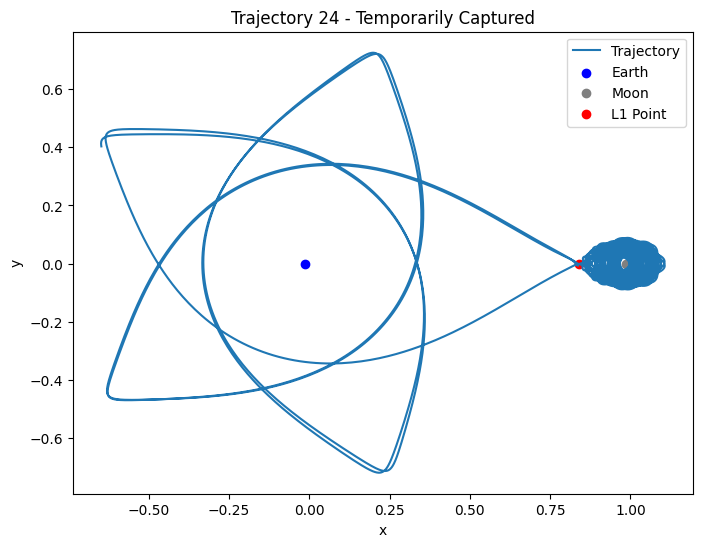

Trajectory 25 is temporarily captured by the Moon.


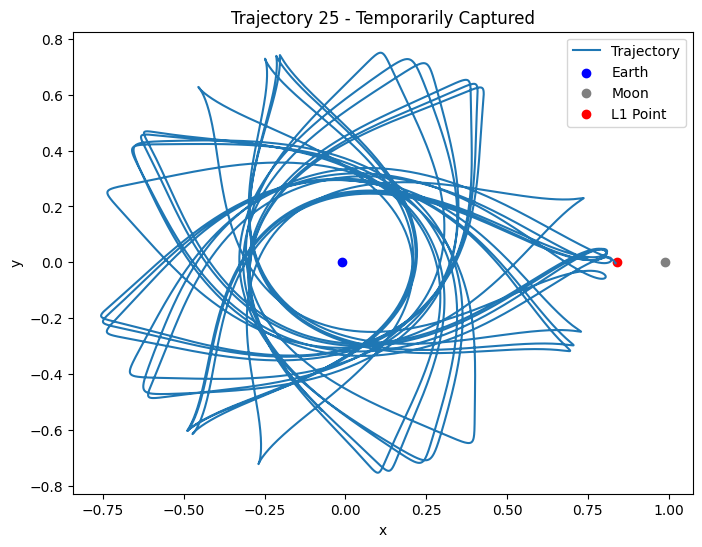

KeyboardInterrupt: 

In [ ]:
# Monte Carlo simulation of various initial conditions near L1
num_samples = 100
initial_states = []
#L1 = compute_L1_coordinates(G, mu, M1, M2)

for _ in range(num_samples):
    # Randomly perturb position and velocity around L1
    pos_perturb = L1 + np.random.uniform(-0.1, 0.1, size=3)
    vel_perturb = np.random.uniform(-0.01, 0.01, size=3)
    initial_states.append(np.concatenate((pos_perturb, vel_perturb)))

    # Integrate each trajectory and analyze
    t, x, y, z, vx, vy, vz, jacobi_constants = trajectory_analysis(mu, masses, initial_states[-1], t_span, dt)
    # Check energy of trajectory and determine if it is temporarily captured by the moon
    if np.any(jacobi_constants < jacobi_0):
        print(f"Trajectory {len(initial_states)} is temporarily captured by the Moon.")
        # plot trajectory
        plt.figure(figsize=(8, 6))
        plt.plot(x, y, label='Trajectory')
        plt.scatter(pos_earth[0], pos_earth[1], color='blue', label='Earth')
        plt.scatter(pos_moon[0], pos_moon[1], color='gray', label='Moon')
        plt.scatter(L1[0], L1[1], color='red', label='L1 Point')
        plt.xlabel('x')
        plt.ylabel('y') 
        plt.title(f'Trajectory {len(initial_states)} - Temporarily Captured')
        plt.legend()
        plt.show()
    
    